In [1]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [4]:
# paths
DATA_DIR = Path(r"D:\dev\internship\Advantal\VDD-ComparativeAnalysis")

TRAINING_OUTPUT_DIR = DATA_DIR / "outputs" / "training"
EVALUATION_OUTPUT_DIR = DATA_DIR / "outputs" / "evaluation"
COMPARISON_OUTPUT_DIR = DATA_DIR / "outputs" / "comparison"

COMPARISON_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [5]:
#load results
evaluation = pd.read_csv(EVALUATION_OUTPUT_DIR / "evaluation_results.csv")
training = []
for model in evaluation["Model"]:
    training.append(pd.read_csv(TRAINING_OUTPUT_DIR / f"{model}_training_info.csv"))
training = pd.concat(training, ignore_index=True)
comparison = evaluation.merge(training, on="Model")
comparison

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,Loss,Epochs,Best Train Accuracy,Best Validation Accuracy,Best Train Loss,Best Validation Loss,Training Time (sec)
0,custom_cnn,0.477477,0.425349,0.440118,0.477477,0.445059,1.288558,20,0.571494,0.476152,0.969139,1.215505,2822.04
1,vgg16,0.515315,0.502434,0.510320,0.515315,0.507838,2.053815,20,0.444063,0.503638,2.799121,1.942352,1982.95
2,mobilenetv2,0.563964,0.519527,0.557603,0.563964,0.543237,1.090534,20,0.536033,0.536783,1.098210,1.099369,2054.49
3,densenet121,0.535135,0.483689,0.526089,0.535135,0.514955,1.099862,20,0.514299,0.540016,1.168677,1.103589,4096.63


In [ ]:
# save comparison results
comparison.to_csv(COMPARISON_OUTPUT_DIR / "comparison_results.csv", index=False)
comparison

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,Loss,Epochs,Best Train Accuracy,Best Validation Accuracy,Best Train Loss,Best Validation Loss,Training Time (sec)
0,custom_cnn,0.477477,0.425349,0.440118,0.477477,0.445059,1.288558,20,0.571494,0.476152,0.969139,1.215505,2822.04
1,vgg16,0.515315,0.502434,0.510320,0.515315,0.507838,2.053815,20,0.444063,0.503638,2.799121,1.942352,1982.95
2,mobilenetv2,0.563964,0.519527,0.557603,0.563964,0.543237,1.090534,20,0.536033,0.536783,1.098210,1.099369,2054.49
3,densenet121,0.535135,0.483689,0.526089,0.535135,0.514955,1.099862,20,0.514299,0.540016,1.168677,1.103589,4096.63


In [8]:
colors = [
    "#A7C7E7",   # custom CNN
    "#B7E4C7",   # VGG16
    "#FDE68A",   # mobilenetV2
    "#F8BBD0"    # densenet121
]

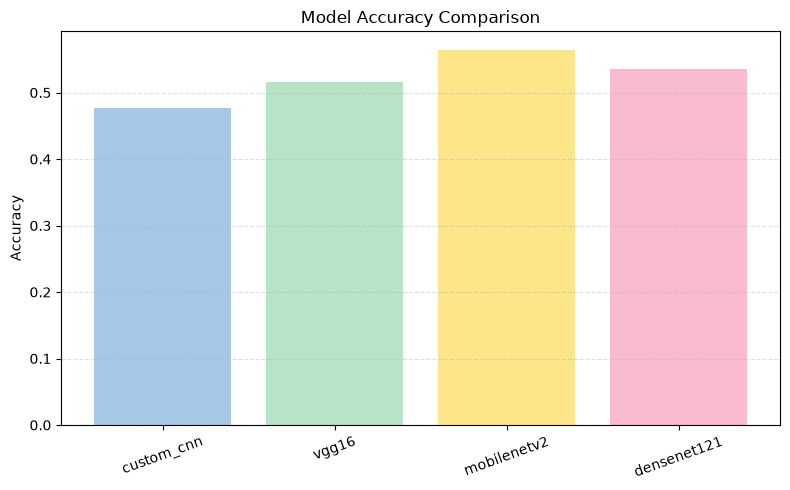

In [10]:
plt.figure(figsize=(8,5))
plt.bar(comparison["Model"], comparison["Accuracy"], color=colors)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(COMPARISON_OUTPUT_DIR / "accuracy_comparison.png", dpi=300)
plt.show()

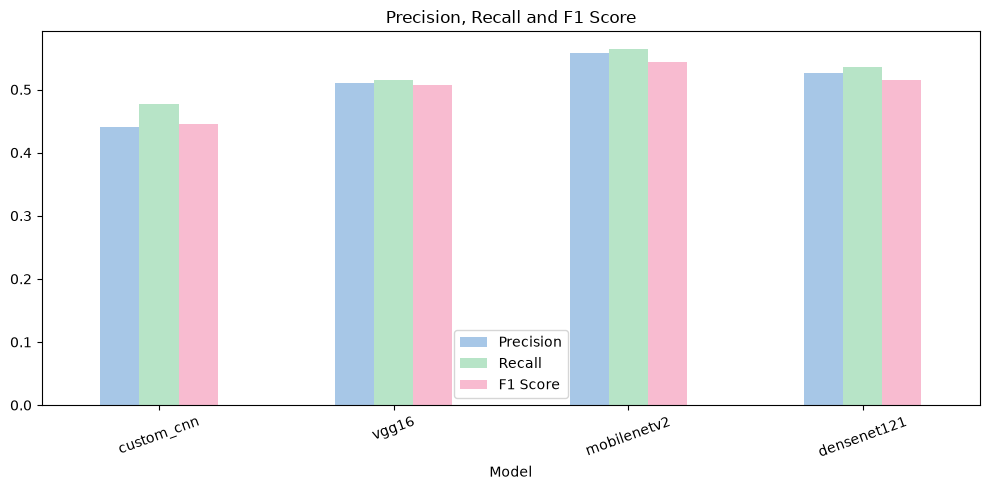

In [15]:
#precision recall F1
metric_colors = [
    "#A7C7E7",   # precision
    "#B7E4C7",   # recall
    "#F8BBD0"    # F1
]
metrics = comparison.set_index("Model")[
    [
        "Precision",
        "Recall",
        "F1 Score"
    ]
]
metrics.plot(kind="bar", figsize=(10,5), color=metric_colors)
plt.title("Precision, Recall and F1 Score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(COMPARISON_OUTPUT_DIR / "precision_recall_f1.png", dpi=300)
plt.show()

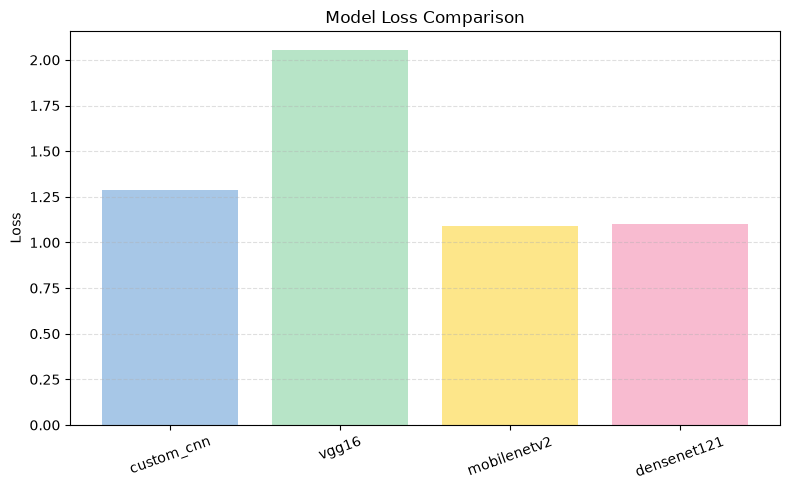

In [12]:
#loss comparison
plt.figure(figsize=(8,5))
plt.bar(comparison["Model"], comparison["Loss"], color=colors)
plt.title("Model Loss Comparison")
plt.ylabel("Loss")
plt.xticks(rotation=20)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(COMPARISON_OUTPUT_DIR / "loss_comparison.png", dpi=300)
plt.show()

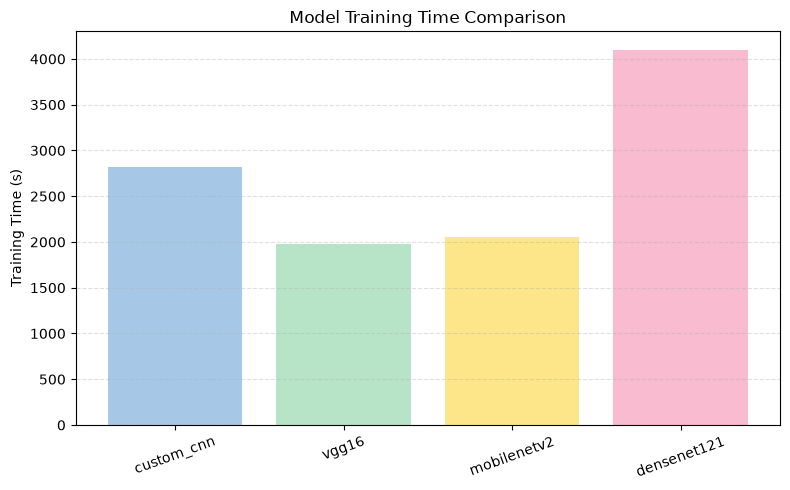

In [14]:
#training time
plt.figure(figsize=(8,5))
plt.bar(comparison["Model"], comparison["Training Time (sec)"], color=colors)
plt.title("Model Training Time Comparison")
plt.ylabel("Training Time (s)")
plt.xticks(rotation=20)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(COMPARISON_OUTPUT_DIR / "training_time.png", dpi=300)
plt.show()

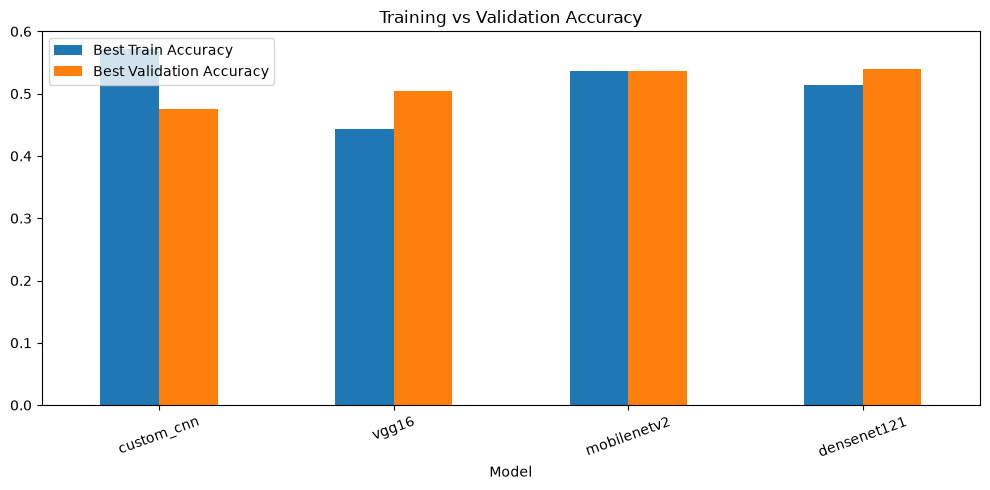

In [16]:
#training vs validation accuracy
accuracy = comparison.set_index("Model")[
    [
        "Best Train Accuracy",
        "Best Validation Accuracy"
    ]
]
accuracy.plot(kind="bar", figsize=(10,5))
plt.title("Training vs Validation Accuracy")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(COMPARISON_OUTPUT_DIR / "train_validation_accuracy.png", dpi=300)
plt.show()

In [17]:
#final ranking
ranking = comparison.sort_values(
    by=[
        "Accuracy",
        "F1 Score",
        "Balanced Accuracy"
    ],
    ascending=False
).reset_index(drop=True)
ranking.index += 1
ranking

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,Loss,Epochs,Best Train Accuracy,Best Validation Accuracy,Best Train Loss,Best Validation Loss,Training Time (sec)
1,mobilenetv2,0.563964,0.519527,0.557603,0.563964,0.543237,1.090534,20,0.536033,0.536783,1.098210,1.099369,2054.49
2,densenet121,0.535135,0.483689,0.526089,0.535135,0.514955,1.099862,20,0.514299,0.540016,1.168677,1.103589,4096.63
3,vgg16,0.515315,0.502434,0.510320,0.515315,0.507838,2.053815,20,0.444063,0.503638,2.799121,1.942352,1982.95
4,custom_cnn,0.477477,0.425349,0.440118,0.477477,0.445059,1.288558,20,0.571494,0.476152,0.969139,1.215505,2822.04


In [18]:
#save ranking
ranking.to_csv(COMPARISON_OUTPUT_DIR / "model_ranking.csv")
ranking

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,Loss,Epochs,Best Train Accuracy,Best Validation Accuracy,Best Train Loss,Best Validation Loss,Training Time (sec)
1,mobilenetv2,0.563964,0.519527,0.557603,0.563964,0.543237,1.090534,20,0.536033,0.536783,1.098210,1.099369,2054.49
2,densenet121,0.535135,0.483689,0.526089,0.535135,0.514955,1.099862,20,0.514299,0.540016,1.168677,1.103589,4096.63
3,vgg16,0.515315,0.502434,0.510320,0.515315,0.507838,2.053815,20,0.444063,0.503638,2.799121,1.942352,1982.95
4,custom_cnn,0.477477,0.425349,0.440118,0.477477,0.445059,1.288558,20,0.571494,0.476152,0.969139,1.215505,2822.04


In [19]:
#best model summary
best = ranking.iloc[0]
print("BEST PERFORMING MODEL")
print(f"Model               : {best['Model']}")
print(f"Accuracy            : {best['Accuracy']:.4f}")
print(f"Balanced Accuracy   : {best['Balanced Accuracy']:.4f}")
print(f"Precision           : {best['Precision']:.4f}")
print(f"Recall              : {best['Recall']:.4f}")
print(f"F1 Score            : {best['F1 Score']:.4f}")
print(f"Loss                : {best['Loss']:.4f}")
print(f"Training Time (sec) : {best['Training Time (sec)']:.2f}")

BEST PERFORMING MODEL
Model               : mobilenetv2
Accuracy            : 0.5640
Balanced Accuracy   : 0.5195
Precision           : 0.5576
Recall              : 0.5640
F1 Score            : 0.5432
Loss                : 1.0905
Training Time (sec) : 2054.49


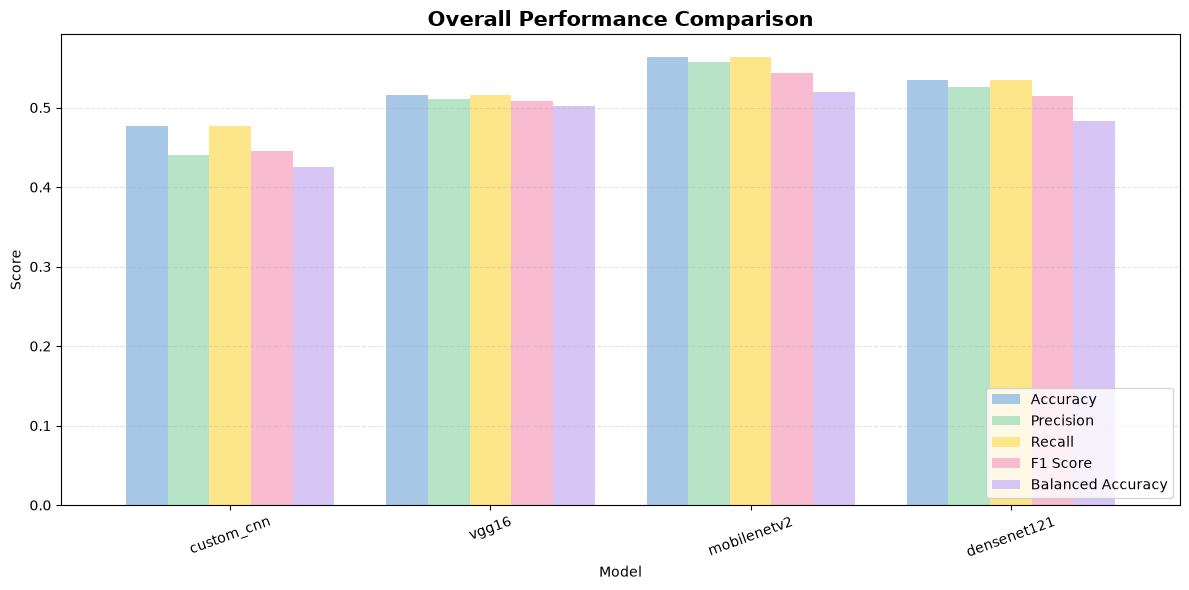

In [20]:
#overall performance comparison
overall = comparison.set_index("Model")[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Balanced Accuracy"
    ]
]
overall_colors = [
    "#A7C7E7",   # Accuracy
    "#B7E4C7",   # Precision
    "#FDE68A",   # Recall
    "#F8BBD0",   # F1
    "#D7C6F5"    # Balanced Accuracy
]
ax = overall.plot(
    kind="bar",
    figsize=(12,6),
    color=overall_colors,
    width=0.8
)
plt.title(
    "Overall Performance Comparison",
    fontsize=15,
    fontweight="bold"
)
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.grid(axis="y", linestyle="--", alpha=0.35)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(COMPARISON_OUTPUT_DIR / "overall_performance.png", dpi=300)
plt.show()

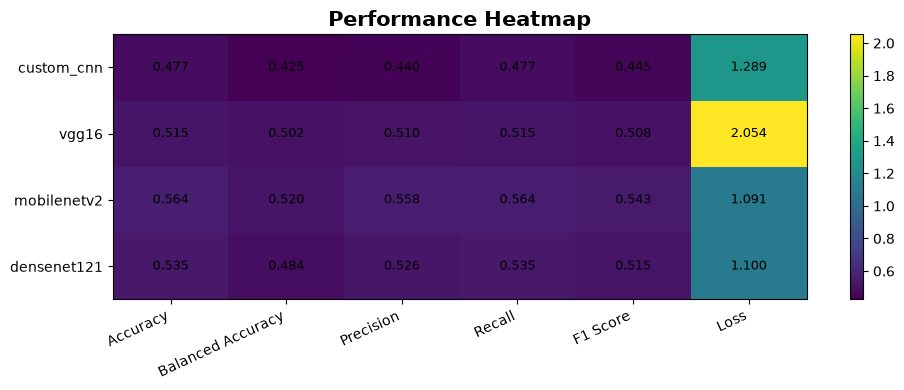

In [21]:
#heatmap
heatmap_data = comparison.set_index("Model")[
    [
        "Accuracy",
        "Balanced Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Loss"
    ]
]
fig, ax = plt.subplots(figsize=(10,4))
im = ax.imshow(
    heatmap_data.values,
    aspect="auto"
)
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(
    heatmap_data.columns,
    rotation=25,
    ha="right"
)
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)
plt.colorbar(im)
for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        ax.text(
            j,
            i,
            f"{heatmap_data.iloc[i,j]:.3f}",
            ha="center",
            va="center",
            fontsize=9
        )
plt.title(
    "Performance Heatmap",
    fontsize=15,
    fontweight="bold"
)
plt.tight_layout()
plt.savefig(COMPARISON_OUTPUT_DIR / "performance_heatmap.png", dpi=300)
plt.show()